### Name : Ansh Yadav
### Roll no : 36
### Course : M.S.C(CS) - 8
### Subject : Machine Learning

### K means, Fuzzy c means, SVM, Decision tree, Random Forest, Hyper Parameter tuning

# ✅ Q1: SVM Classifier on Breast Cancer Dataset

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Preprocess
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Try different kernels
for kernel in ['linear', 'rbf', 'poly']:
    model = SVC(kernel=kernel)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\nKernel: {kernel}")
    print(classification_report(y_test, y_pred))

# Hyperparameter tuning
param_grid = {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear'], 'gamma': ['scale', 'auto']}
grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train, y_train)
print("\nBest Parameters from GridSearch:", grid.best_params_)



Kernel: linear
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114


Kernel: rbf
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Kernel: poly
              precision    recall  f1-score   support

           0       1.00      0.65      0.79        43
           1       0.83      1.00      0.90        71

    accuracy                           0.87       114
   macro avg       0.91      0.83      0.85       114
weighted avg       0.89      0.

# ✅ Q2: Decision Tree on Iris Dataset

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


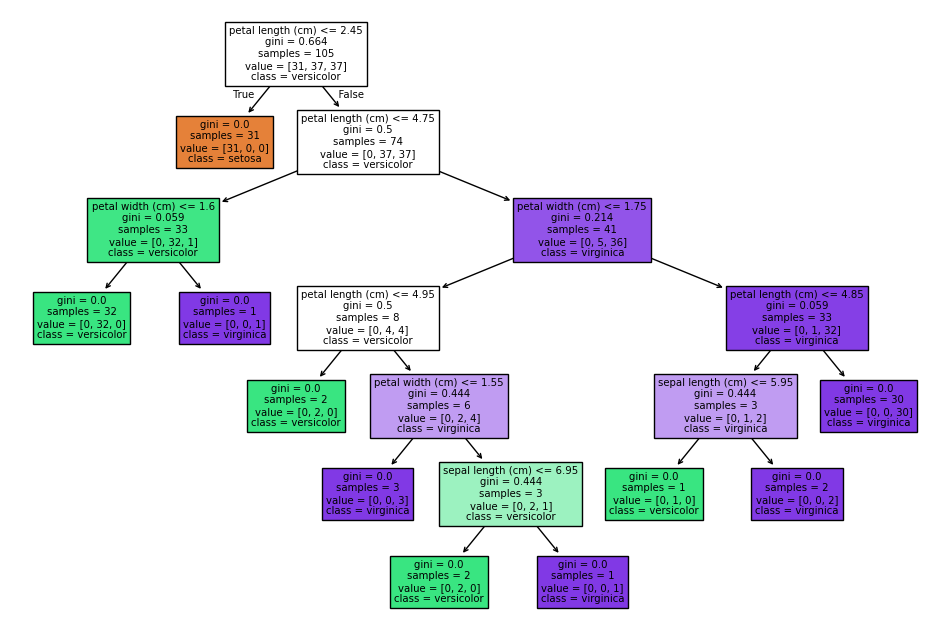

Best Params: {'criterion': 'gini', 'max_depth': 3}


In [2]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Load & split
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.3, random_state=42)

# Train
clf = DecisionTreeClassifier().fit(X_train, y_train)
print(iris.feature_names)
print(iris.target_names)
# Visualize
plt.figure(figsize=(12, 8))
plot_tree(clf, filled=True, feature_names=iris.feature_names, class_names=iris.target_names)
plt.show()

# Hyperparameter tuning
param_grid = {'max_depth': [2, 3, 4, 5], 'criterion': ['gini', 'entropy']}
grid = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best Params:", grid.best_params_)


# ✅ Q3: Random Forest on Titanic Dataset

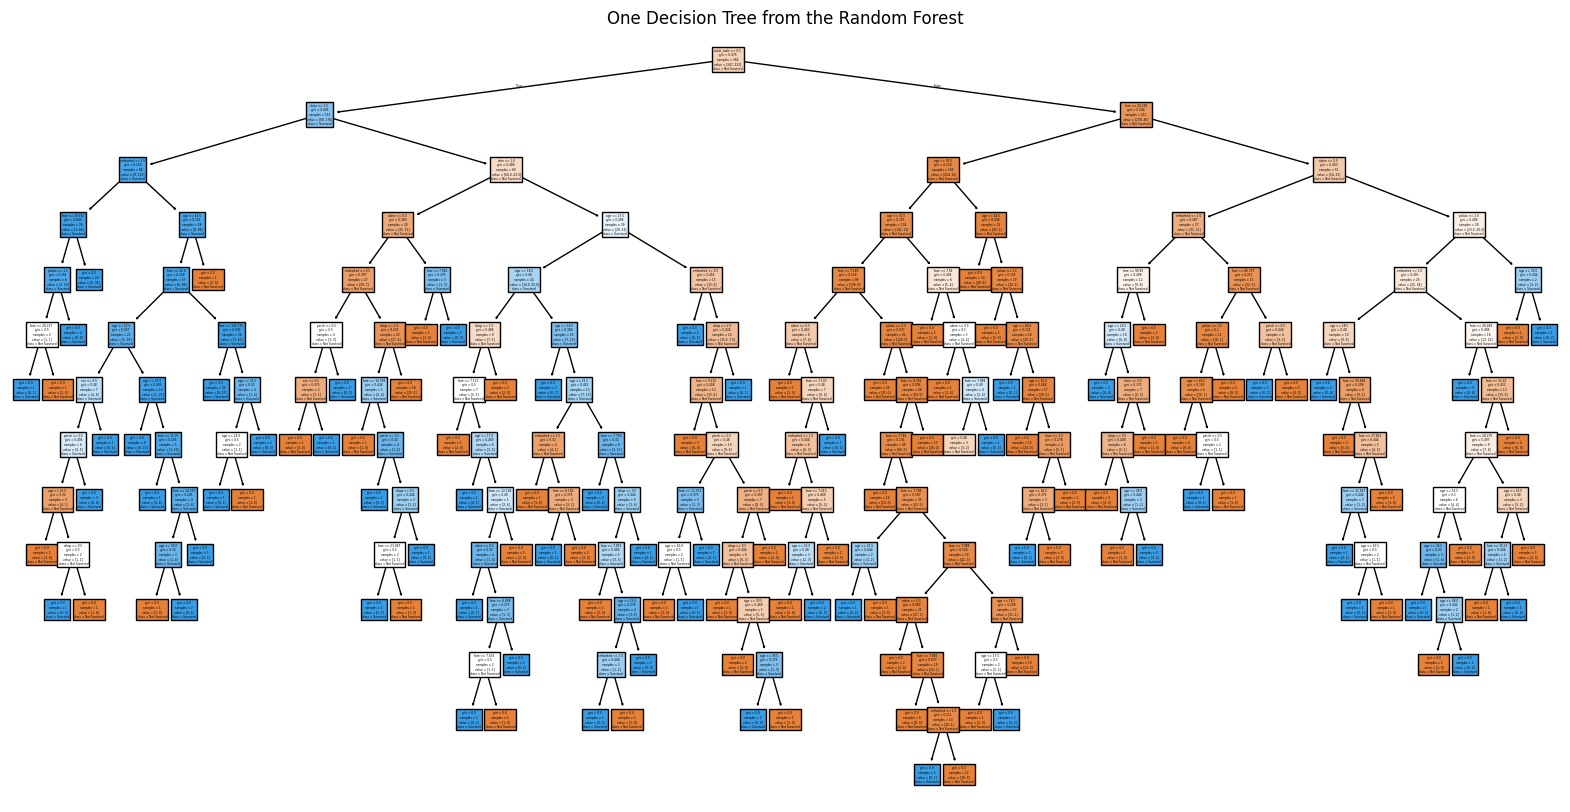

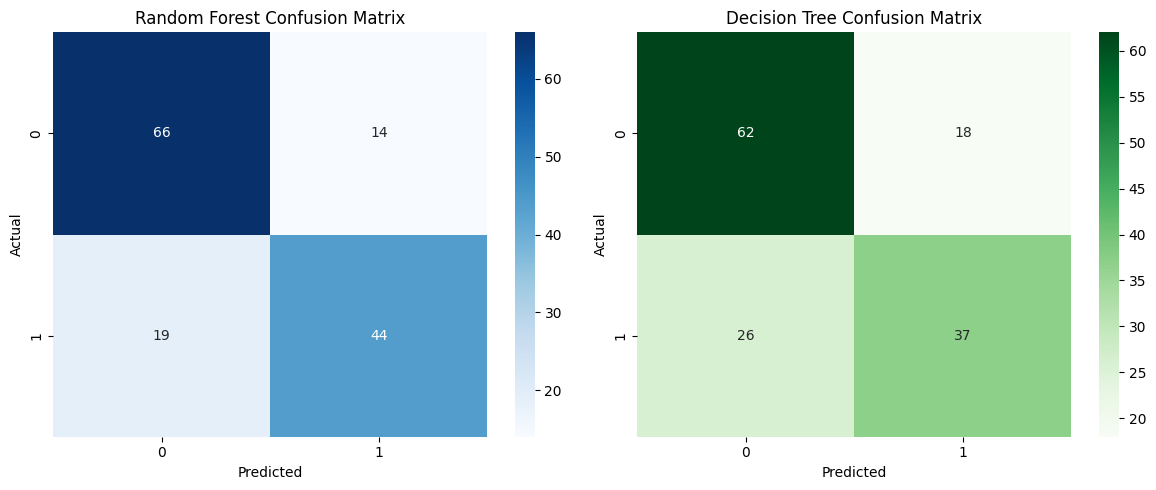

[[66 14]
 [19 44]] 

 [[62 18]
 [26 37]]


In [3]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np

# Load dataset
titanic = sns.load_dataset('titanic')

# Feature engineering
titanic.drop(['deck', 'embark_town', 'alive'], axis=1, inplace=True)
titanic.dropna(inplace=True)
for col in ['sex', 'embarked', 'class', 'who', 'adult_male', 'alone']:
    titanic[col] = LabelEncoder().fit_transform(titanic[col])

# Define features and labels
X = titanic.drop('survived', axis=1)
y = titanic['survived']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest model
rf = RandomForestClassifier(random_state=42).fit(X_train, y_train)
rf_cm = confusion_matrix(y_test, rf.predict(X_test))

from sklearn.tree import plot_tree

# Plot one tree from the forest
plt.figure(figsize=(20,10))
plot_tree(rf.estimators_[0], feature_names=X.columns, class_names=['Not Survived', 'Survived'], filled=True)
plt.title("One Decision Tree from the Random Forest")
plt.show()


# Decision Tree model
dt = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
dt_cm = confusion_matrix(y_test, dt.predict(X_test))

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Random Forest Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Decision Tree Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()
print(rf_cm,"\n\n", dt_cm)

# ✅ Q4: KNN on Wine Quality Dataset

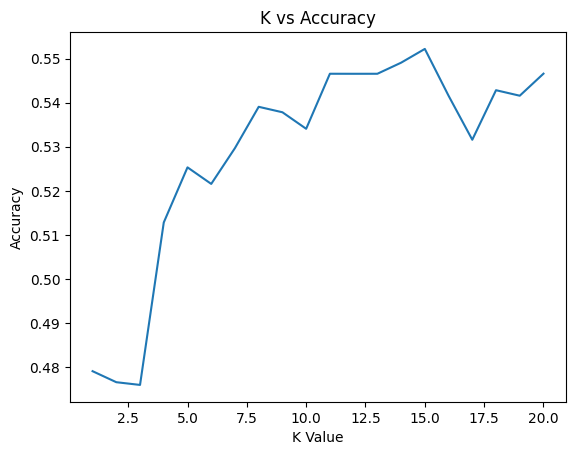

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        15
           5       0.62      0.69      0.65       141
           6       0.50      0.56      0.53       119
           7       0.59      0.44      0.50        39
           8       0.00      0.00      0.00         5

    accuracy                           0.57       320
   macro avg       0.28      0.28      0.28       320
weighted avg       0.53      0.57      0.54       320



/home/ansh-yadav/.miniconda3/envs/tf-gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ansh-yadav/.miniconda3/envs/tf-gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ansh-yadav/.miniconda3/envs/tf-gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

In [4]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Load dataset
wine = pd.read_csv('./dataset/winequality-red.csv', sep=';')

X = wine.drop('quality', axis=1)
y = wine['quality']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find best K
k_vals = list(range(1, 21))
scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k), X_scaled, y, cv=5).mean() for k in k_vals]

plt.plot(k_vals, scores)
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()

# Train model
best_k = k_vals[scores.index(max(scores))]
knn = KNeighborsClassifier(n_neighbors=best_k)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(classification_report(y_test, y_pred))


# ✅ Q5: K-Means Clustering on Iris

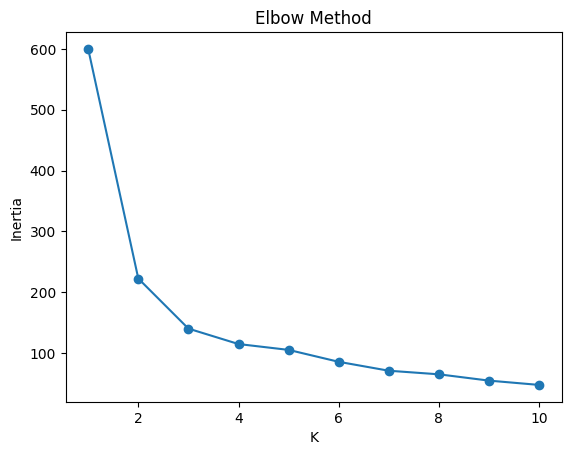

Silhouette score for k=2: 0.5817500491982808
Silhouette score for k=3: 0.4798814508199817
Silhouette score for k=4: 0.3899310446134557
Silhouette score for k=5: 0.3978369199051083
Silhouette score for k=6: 0.30923583433530655


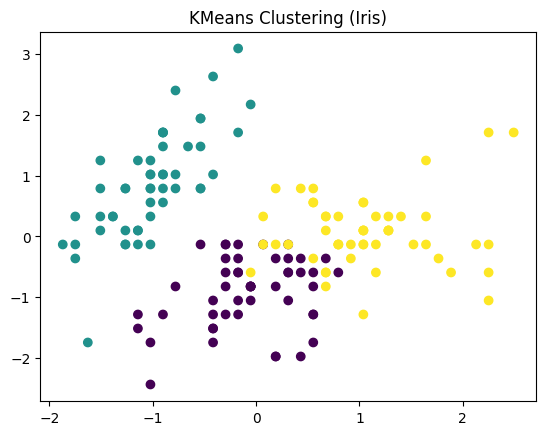

In [5]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load iris
iris = load_iris()
X = iris.data

# Standardize
X_scaled = StandardScaler().fit_transform(X)

# Elbow method
inertias = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(range(1, 11), inertias, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Silhouette Score
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k)
    labels = kmeans.fit_predict(X_scaled)
    print(f"Silhouette score for k={k}: {silhouette_score(X_scaled, labels)}")

# Visualization
kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis')
plt.title('KMeans Clustering (Iris)')
plt.show()


# ✅ Q6: Hierarchical Clustering on Mall Dataset

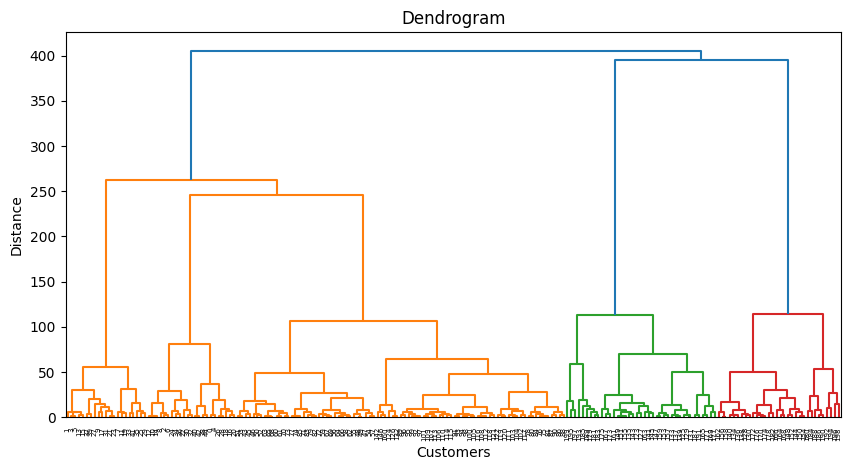

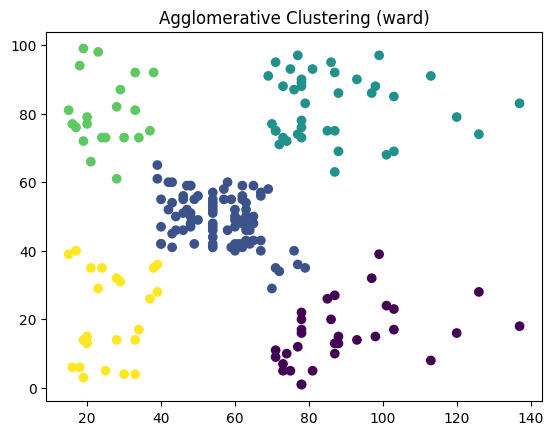

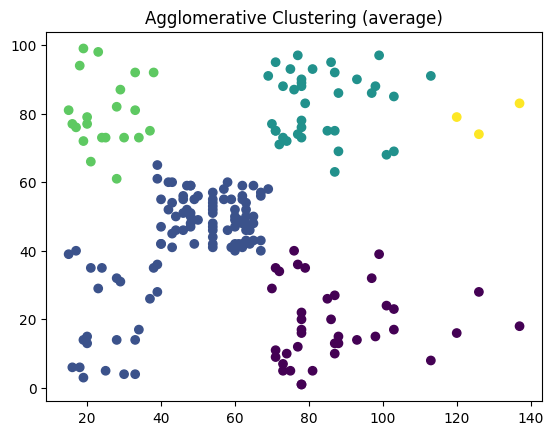

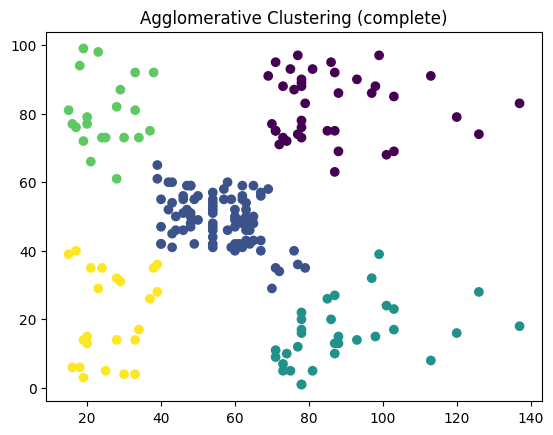

In [6]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
import matplotlib.pyplot as plt
# Load data
mall = pd.read_csv("./dataset/Mall_Customers.csv")
X = mall[['Annual Income (k$)', 'Spending Score (1-100)']]

# Dendrogram
plt.figure(figsize=(10, 5))
sch.dendrogram(sch.linkage(X, method='ward'))
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

# Agglomerative Clustering
for method in ['ward', 'average', 'complete']:
    cluster = AgglomerativeClustering(n_clusters=5, linkage=method)
    labels = cluster.fit_predict(X)
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=labels)
    plt.title(f'Agglomerative Clustering ({method})')
    plt.show()


# ✅ Q7 - Part A: K-Means Clustering from Scratch

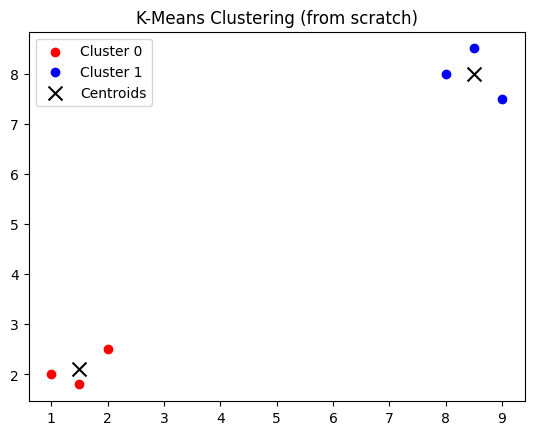

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset
X = np.array([
    [1.0, 2.0],
    [1.5, 1.8],
    [2.0, 2.5],
    [8.0, 8.0],
    [8.5, 8.5],
    [9.0, 7.5]
])

# Initialize
def kmeans(X, k=2, max_iters=100):
    np.random.seed(42)
    # Randomly select initial centroids
    centroids = X[np.random.choice(X.shape[0], k, replace=False)]
    
    for iteration in range(max_iters):
        # Compute distances and assign clusters
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        clusters = np.argmin(distances, axis=1)
        
        # Update centroids
        new_centroids = np.array([X[clusters == i].mean(axis=0) for i in range(k)])

        # Convergence check
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    return centroids, clusters

centroids, clusters = kmeans(X, k=2)

# Plotting
colors = ['red', 'blue']
for i in range(2):
    plt.scatter(X[clusters == i][:, 0], X[clusters == i][:, 1], c=colors[i], label=f'Cluster {i}')
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='x', s=100, label='Centroids')
plt.legend()
plt.title("K-Means Clustering (from scratch)")
plt.show()


# ✅ Q7 - Part B: Fuzzy C-Means Clustering from Scratch

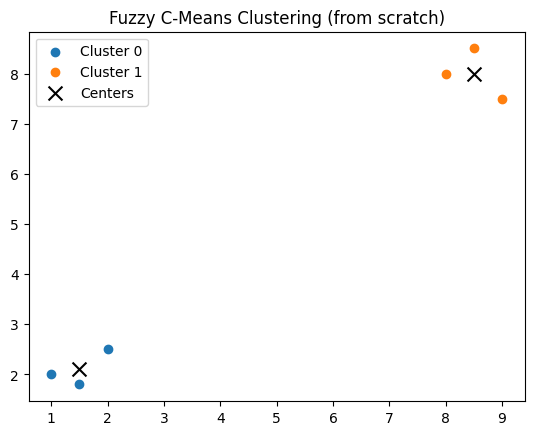

In [8]:
def fuzzy_c_means(X, c=2, m=2, max_iter=100, epsilon=1e-5):
    n_samples = X.shape[0]
    np.random.seed(42)
    
    # Initialize membership matrix randomly
    U = np.random.dirichlet(np.ones(c), size=n_samples)
    
    for iteration in range(max_iter):
        # Compute cluster centers
        centers = (U ** m).T @ X / np.sum(U ** m, axis=0)[:, None]
        
        # Calculate distances
        dist = np.linalg.norm(X[:, np.newaxis] - centers, axis=2)
        dist = np.fmax(dist, 1e-10)  # avoid division by zero
        
        # Update membership matrix
        U_new = 1.0 / np.sum((dist[:, :, np.newaxis] / dist[:, np.newaxis, :]) ** (2 / (m - 1)), axis=2)
        
        # Check for convergence
        if np.linalg.norm(U_new - U) < epsilon:
            break
        U = U_new

    return centers, U

centers, membership = fuzzy_c_means(X, c=2)
labels = np.argmax(membership, axis=1)

# Plotting
for i in range(2):
    plt.scatter(X[labels == i][:, 0], X[labels == i][:, 1], label=f'Cluster {i}')
plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='x', s=100, label='Centers')
plt.title("Fuzzy C-Means Clustering (from scratch)")
plt.legend()
plt.show()


In [9]:
!pip install -q fuzzy-c-means

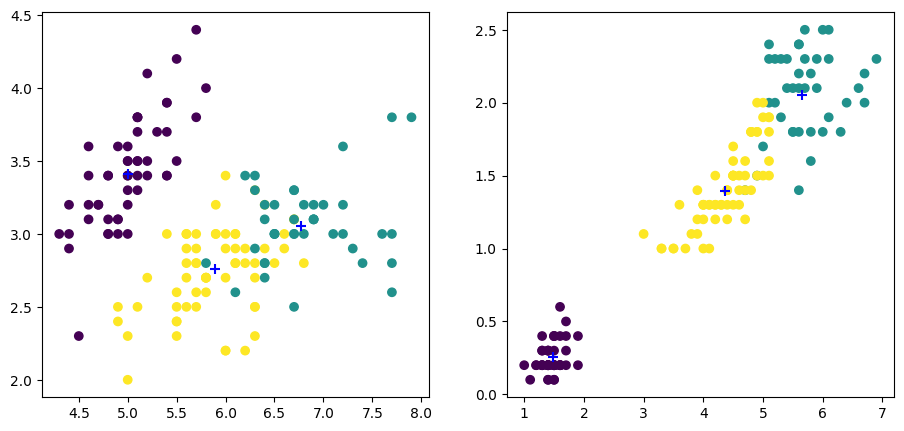

In [10]:
from fcmeans import FCM
from sklearn.datasets import load_iris
iris = load_iris()
x = pd.DataFrame(iris.data,columns=iris.feature_names)
y = pd.DataFrame(iris.target,columns=['Species'])
fcm = FCM(n_clusters=3)
fcm.fit(x.values)
fcm_centers = fcm.centers
fcm_labels = fcm.predict(x.values)
fcm_centers = pd.DataFrame(fcm_centers)
f,axes = plt.subplots(1,2,figsize=(11,5))
axes[0].scatter(list(x.iloc[:,0]),list(x.iloc[:,1]),c=fcm_labels)
axes[1].scatter(list(x.iloc[:,2]),list(x.iloc[:,3]),c=fcm_labels)
axes[0].scatter(fcm_centers[0],fcm_centers[1],s=50,marker='+',c='b')
axes[1].scatter(fcm_centers[2],fcm_centers[3],s=50,marker='+',c='b')

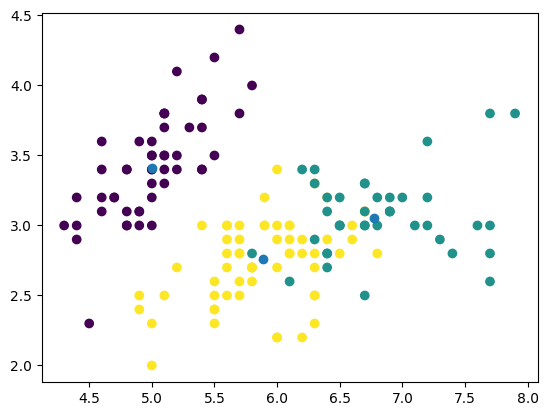

In [11]:
plt.scatter(x['sepal length (cm)'],x['sepal width (cm)'],c=fcm_labels)
plt.scatter(fcm_centers[0],fcm_centers[1])
plt.show()